# Augmented Reality with Planar Homographies

### Setup: Imports and Loading Videos

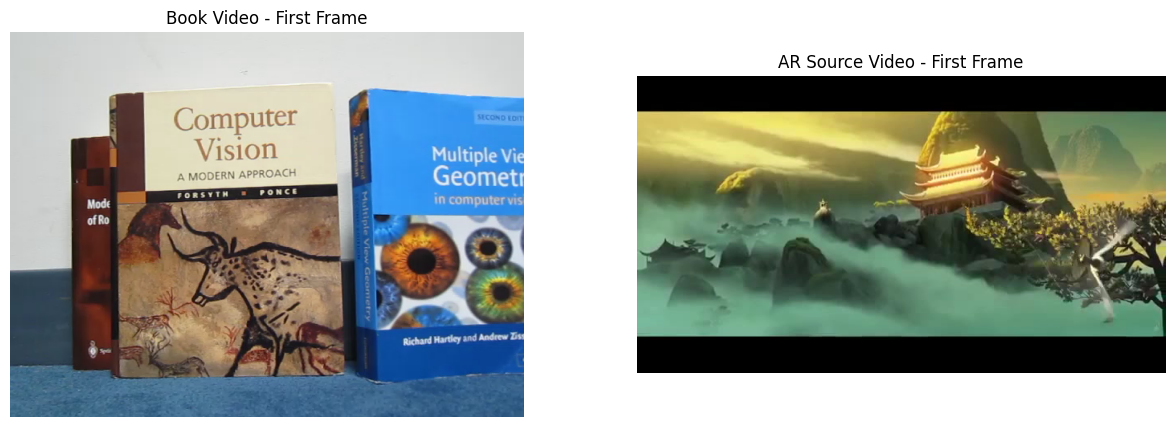

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

book_vid = cv2.VideoCapture('data/book.mov')
ar_vid = cv2.VideoCapture('data/ar_source.mov')

book_cover = cv2.imread('data/cv_cover.jpg')

# first frame of each video for testing
ret_book, book_frame_bgr = book_vid.read()
ret_ar, ar_frame_bgr = ar_vid.read()

# convert BGR to RGB for plotting
book_frame = cv2.cvtColor(book_frame_bgr, cv2.COLOR_BGR2RGB)
ar_frame = cv2.cvtColor(ar_frame_bgr, cv2.COLOR_BGR2RGB)

# width and height of book cover and ar video
h_book, w_book, _ = book_cover.shape
h_ar, w_ar, _ = ar_frame.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(book_frame)
ax1.set_title('Book Video - First Frame')
ax1.axis('off')

ax2.imshow(ar_frame)
ax2.set_title('AR Source Video - First Frame')
ax2.axis('off')
        
plt.show()

### Getting Correspondences
The first step is to find the correspondences between the image book and the first frame of the video. 
- Use SIFT descriptor from opencv library to find keypoints in each image.
- Use the brute force matcher from opencv to get the correspondences. 
- Use the matching way as KNN with size 2
- apply ratio checking between the best 2 matches to filter the good correspondences.
- Choose 50 correspondences and plot the book image, the first video frame and the matches as shown below.

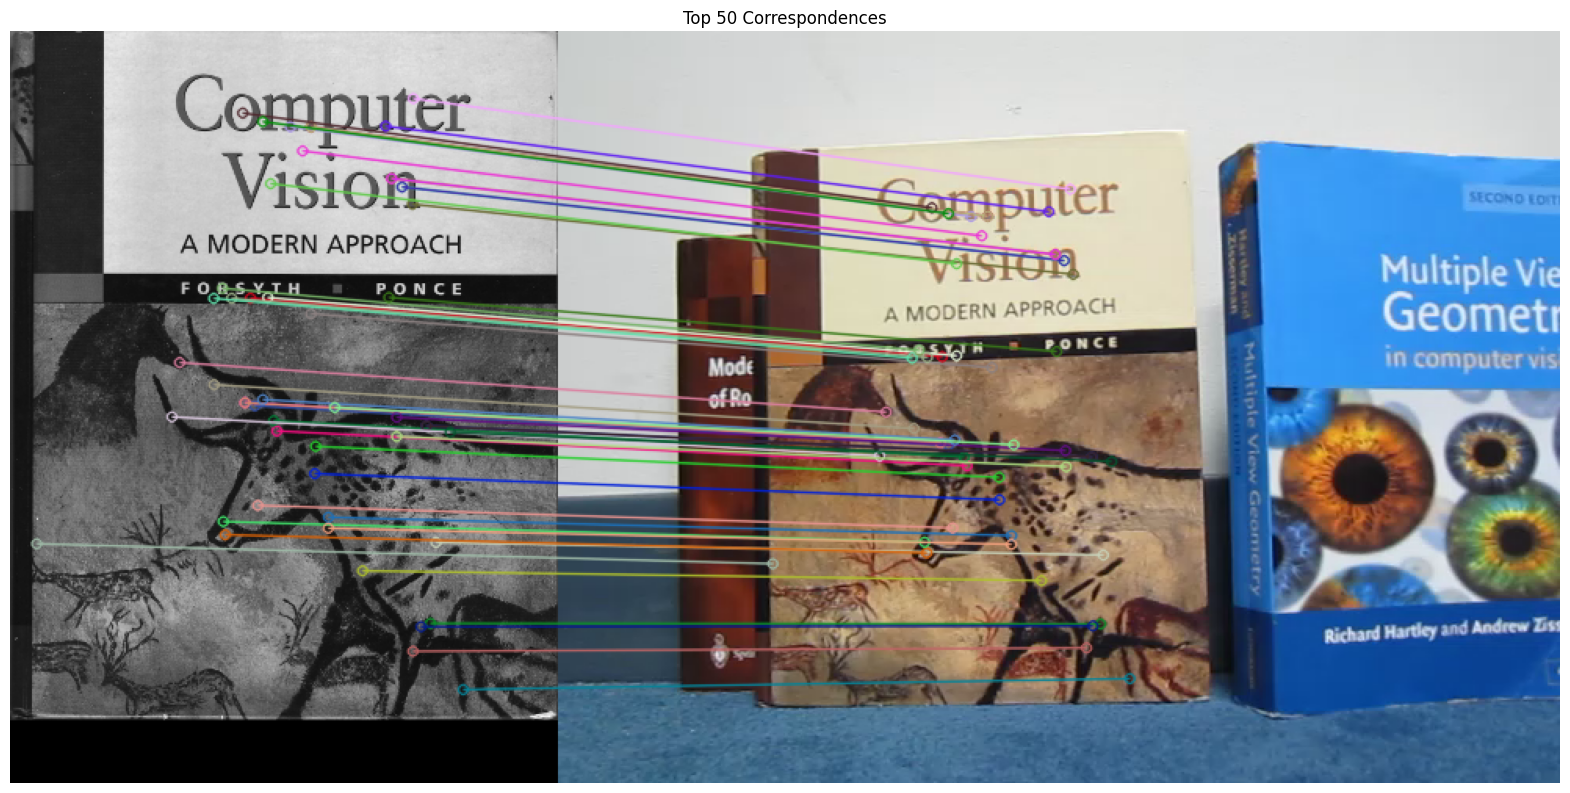

In [95]:
# grayscale for feature extraction
gray_cover = cv2.cvtColor(book_cover, cv2.COLOR_RGB2GRAY)
gray_book = cv2.cvtColor(book_frame, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()

# get keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray_cover, None)
kp2, des2 = sift.detectAndCompute(gray_book, None)

# brute force matcher
bf = cv2.BFMatcher()

# KNN Matching with k=2
matches = bf.knnMatch(des1, des2, k=2)

# ratio checking for good correspondences
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# get top 50 correspondences
good_matches = sorted(good_matches, key=lambda x: x.distance)
top_50_matches = good_matches[:50] 

# draw the matches
matched_img = cv2.drawMatches(
    book_cover, kp1, 
    book_frame, kp2, 
    top_50_matches, None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(matched_img)
plt.title('Top 50 Correspondences')
plt.axis('off')
plt.show()

### Compute the Homography Parameters
- A function is needed that takes a set of corresponding image points and computes the associated 3Ãƒâ€”3 homography matrix H. 
- This matrix transforms any point p in one view to its corresponding homogeneous coordinates in the second view, pÃ¢â‚¬â„¢, such that pÃ¢â‚¬â„¢ = Hp. 
- Note that p and pÃ¢â‚¬â„¢ are both 3D points in homogeneous coordinates. 
- The function should take a list of n >= 4 pairs of corre sponding points from the two views, where each point is specified with its 2D image coordinates. 
#### How to solve
- We can set up a solution using a system of linear equations Ax = b, where the 8 unknowns of H are stacked into an 8-vector x , the 2n-vector b contains image points from one view, and the 2n Ãƒâ€” 8 matrix A is filled appropriately so that the full system gives us ÃŽÂ»p = Hp. 
- There are only 8 unknowns in H because we set H3,3 = 1. 
- Solve for the unknown homography matrix parameters. 

$$H = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & 1 \end{bmatrix}$$

The relationship $p' = Hp$ gives us the following equations for the mapped coordinates:

$$x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + 1}$$
$$y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + 1}$$

By multiplying by the denominators and rearranging the terms to isolate the 8 unknowns, we can formulate a system of linear equations $Ax = b$. For a single corresponding point pair $(x, y)$ and $(x', y')$, the $2 \times 8$ sub-matrix $A_i$ and $2 \times 1$ sub-vector $b_i$ are structured as follows:

$$A_i = \begin{bmatrix} x & y & 1 & 0 & 0 & 0 & -x \cdot x' & -y \cdot x' \\ 0 & 0 & 0 & x & y & 1 & -x \cdot y' & -y \cdot y' \end{bmatrix}$$

$$b_i = \begin{bmatrix} x' \\ y' \end{bmatrix}$$

The vector $x$ contains our 8 unknowns:

$$x = \begin{bmatrix} h_{11} \\ h_{12} \\ h_{13} \\ h_{21} \\ h_{22} \\ h_{23} \\ h_{31} \\ h_{32} \end{bmatrix}$$

By stacking the $A_i$ and $b_i$ matrices for $n \ge 4$ point pairs, we create the full $2n \times 8$ matrix $A$ and the $2n$-vector $b$. We can then solve for the 8-vector $x$ using the Least Squares method.

- Verify that the homography matrix your function computes is correct by mapping a few image points from one view to the other, and displaying them on top of each respective image. 
- Be sure to handle homogenous and non-homogenous coordinates correctly.

In [96]:
def compute_homography_parameters(src_pts, dst_pts):
    """
    Computes a 3x3 homography matrix H that maps points from src to dst,
    i.e. dst_pt ~ H @ src_pt (in homogeneous coordinates).

    Method: Direct Linear Transform (DLT).
    For each point pair (x,y) -> (u,v), the homography relationship gives:
        u = (h11*x + h12*y + h13) / (h31*x + h32*y + 1)
        v = (h21*x + h22*y + h23) / (h31*x + h32*y + 1)

    Rearranging to isolate unknowns on the left side:
        h11*x + h12*y + h13           - h31*x*u - h32*y*u = u
        h21*x + h22*y + h23 - h31*x*v - h32*y*v           = v

    This gives 2 linear equations per point pair.
    With n >= 4 pairs we get an overdetermined system A @ x_vec = b
    which is solved with least squares.
    """
    A = []   # will become a (2n x 8) matrix
    b = []   # will become a (2n,) vector of target coordinates

    # variable naming: (x,y) = source point, (u,v) = destination point
    for i in range(len(src_pts)):
        x, y = src_pts[i]
        u, v = dst_pts[i]

        # Row for the x' (u) equation:
        #   [x, y, 1, 0, 0, 0, -x*u, -y*u] @ h_vec = u
        A.append([x, y, 1, 0, 0, 0, -x*u, -y*u])

        # Row for the y' (v) equation:
        #   [0, 0, 0, x, y, 1, -x*v, -y*v] @ h_vec = v
        A.append([0, 0, 0, x, y, 1, -x*v, -y*v])

        b.append(u)
        b.append(v)

    A = np.array(A)   # shape (2n, 8)
    b = np.array(b)   # shape (2n,)

    # Solve A @ x_vec = b for the 8 unknown homography entries using least squares.
    # x_vec = [h11, h12, h13, h21, h22, h23, h31, h32]
    x_vec, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    # Append the fixed h33=1 and reshape from (9,) vector into a 3x3 matrix:
    #   [[h11, h12, h13],
    #    [h21, h22, h23],
    #    [h31, h32,   1]]
    H = np.append(x_vec, 1).reshape(3, 3)

    return H


In [97]:
def forward_warp(src, H, output_shape):
    """
    Forward warping: pushes every pixel of `src` through H into the output canvas.

    For each source pixel (xs, ys), compute its destination (xd, yd) = H @ [xs,ys,1],
    then paint src[ys,xs] onto dst[yd,xd].

    Drawback: because multiple source pixels may map to the same destination pixel,
    or some destination pixels may receive no source pixel at all, this can produce
    'holes' (black gaps) in the output. Inverse warping avoids this problem.
    """
    h_out, w_out = output_shape[:2]
    h_src, w_src = src.shape[:2]

    # Build a grid of ALL source pixel coordinates at once (vectorised).
    # xs[i,j]=j, ys[i,j]=i -> flat arrays of x and y coordinates
    xs, ys = np.meshgrid(np.arange(w_src), np.arange(h_src))

    # Stack into homogeneous (3 x N) matrix: each column is [x, y, 1]
    src_coords = np.stack([xs.ravel(), ys.ravel(),
                            np.ones(h_src * w_src)], axis=0).astype(np.float64)

    # Apply homography H: destination = H @ source  (still homogeneous)
    dst_coords = H @ src_coords           # (3, N)
    dst_coords /= dst_coords[2:3, :]      # divide by w to get Cartesian (x', y')

    # Round to nearest integer pixel in the destination image
    xd = np.round(dst_coords[0]).astype(int).reshape(h_src, w_src)
    yd = np.round(dst_coords[1]).astype(int).reshape(h_src, w_src)

    dst = np.zeros((h_out, w_out, src.shape[2]), dtype=src.dtype)

    # Only paint pixels whose destination lands within the output canvas
    valid = (xd >= 0) & (xd < w_out) & (yd >= 0) & (yd < h_out)
    dst[yd[valid], xd[valid]] = src[ys[valid], xs[valid]]

    return dst


def inverse_warp(src, H, output_shape):
    """
    Inverse warping: for every pixel in the OUTPUT image, map BACK to the source
    using the inverse homography H_inv, then copy the source pixel value there.

    This guarantees no holes: every output pixel gets exactly one source lookup.
    Uses nearest-neighbour sampling (fast but slightly blocky edges).
    output_shape is (h, w) or (h, w, c).
    """
    h_out, w_out = output_shape[:2]

    # Invert H so we can go from destination coordinates back to source coordinates
    H_inv = np.linalg.inv(H)

    # Build a grid of ALL destination pixel coordinates at once
    xd, yd = np.meshgrid(np.arange(w_out), np.arange(h_out))

    # Stack into homogeneous (3 x N) matrix
    dst_coords = np.stack([xd.ravel(), yd.ravel(),
                            np.ones(h_out * w_out)], axis=0).astype(np.float64)

    # Map each destination pixel BACK to the source image via H_inv
    src_coords = H_inv @ dst_coords       # (3, N)
    src_coords /= src_coords[2:3, :]      # normalise homogeneous -> Cartesian

    h_src, w_src = src.shape[:2]

    # Round to nearest integer source pixel (nearest-neighbour interpolation)
    xs = np.round(src_coords[0]).astype(int).reshape(h_out, w_out)
    ys = np.round(src_coords[1]).astype(int).reshape(h_out, w_out)

    # Only sample source pixels that actually exist (inside src image bounds)
    valid = (xs >= 0) & (xs < w_src) & (ys >= 0) & (ys < h_src)
    dst = np.zeros((h_out, w_out, src.shape[2]), dtype=src.dtype)
    dst[valid] = src[ys[valid], xs[valid]]

    return dst


def ransac_homography(src_pts, dst_pts, n_iters=1000, threshold=4.0):
    """
    Estimates a robust homography H using RANSAC (RANdom SAmple Consensus).
    Avoids cv2.findHomography — uses our own compute_homography_parameters.
    Returns (H, inlier_mask_bool).

    Why RANSAC?
        Feature matching always includes wrong matches ('outliers').
        Fitting H to ALL matches gives a bad result.
        RANSAC repeatedly tries small random subsets and picks the H
        that explains the MOST matches within a reprojection tolerance.

    Algorithm per iteration:
        1. Pick 4 random point pairs (minimum needed to define a homography).
        2. Compute H_candidate from those 4 pairs.
        3. Project ALL src_pts through H_candidate.
        4. Count how many projected points land within `threshold` pixels of
           their corresponding dst_pts -> these are 'inliers'.
        5. Keep the H_candidate with the most inliers.
    After all iterations, refit H on ALL inliers of the best set for accuracy.
    """
    n = len(src_pts)
    best_H       = None
    best_inliers = np.zeros(n, dtype=bool)

    for _ in range(n_iters):
        # Step 1: randomly sample 4 point pairs (no repeats)
        idx = np.random.choice(n, 4, replace=False)
        try:
            H_cand = compute_homography_parameters(src_pts[idx], dst_pts[idx])
        except Exception:
            continue   # degenerate configuration (collinear pts), skip

        # Step 2: project ALL source points through H_candidate
        # Convert src_pts to homogeneous: shape (N, 3) with last col = 1
        src_h = np.column_stack([src_pts, np.ones(n)])
        proj  = (H_cand @ src_h.T).T    # (N, 3) — projected in homogeneous coords

        # Skip if any point projects to infinity (w ≈ 0)
        denom = proj[:, 2:3]
        if np.any(np.abs(denom) < 1e-8):
            continue

        # Normalise to Cartesian coordinates
        proj /= denom

        # Step 3: compute reprojection error (Euclidean distance) for every point
        errors = np.linalg.norm(proj[:, :2] - dst_pts, axis=1)

        # Step 4: inliers = points within the distance threshold
        inliers = errors < threshold
        if inliers.sum() > best_inliers.sum():
            best_inliers = inliers
            best_H       = H_cand

    # Final refit: once we know which points are inliers, recompute H
    # using ALL of them — more data -> better least-squares solution
    if best_inliers.sum() >= 4:
        best_H = compute_homography_parameters(
            src_pts[best_inliers], dst_pts[best_inliers]
        )

    return best_H, best_inliers


def is_valid_homography(H, frame_w, frame_h, w_book, h_book):
    """
    Sanity-checks whether homography H produces a geometrically plausible
    book projection in the video frame.

    Runs three checks — if any fail, returns (False, None, None):
      1. Convexity:  the four projected book corners must form a convex quad
                     (not folded / self-intersecting). Detected via cross-product
                     signs of consecutive edge vectors.
      2. Area:       the projected quad must cover between 0.5% and 85% of the
                     frame area — rejects tiny (distant book) or huge (exploded)
                     projections caused by degenerate H values.
      3. Bounds:     no corner may be more than half the frame width/height
                     outside the frame — rejects extreme off-screen projections.

    If all checks pass, returns (True, corners_float, corners_int32) where
    corners is a (4,2) array of the projected book corner pixel coordinates.
    """
    # Project the four corners of the book cover image through H
    cover = np.array([[0, 0], [w_book - 1, 0],
                      [w_book - 1, h_book - 1], [0, h_book - 1]], dtype=np.float64)
    pts_h = np.column_stack([cover, np.ones(4)])   # (4,3) homogeneous
    proj  = (H @ pts_h.T).T                        # (4,3) projected

    # Reject if any projected point has w ≈ 0 (point at infinity)
    if np.any(np.abs(proj[:, 2]) < 1e-8):
        return False, None, None

    # Convert from homogeneous to 2D pixel coordinates
    corners = proj[:, :2] / proj[:, 2:3]           # (4,2)

    # --- Check 1: Convexity ---
    # For a convex polygon, the cross product of consecutive edge vectors
    # must all have the same sign (all positive = CCW, all negative = CW).
    signs = []
    for i in range(4):
        e1 = corners[(i + 1) % 4] - corners[i]
        e2 = corners[(i + 2) % 4] - corners[(i + 1) % 4]
        signs.append(e1[0] * e2[1] - e1[1] * e2[0])   # 2D cross product
    if not (all(s > 0 for s in signs) or all(s < 0 for s in signs)):
        return False, None, None   # non-convex or self-intersecting quad

    # --- Check 2: Area (Shoelace formula) ---
    area = 0.0
    for i in range(4):
        j = (i + 1) % 4
        area += corners[i, 0] * corners[j, 1]
        area -= corners[j, 0] * corners[i, 1]
    area = abs(area) / 2.0
    frame_area = frame_w * frame_h
    if area < 0.005 * frame_area or area > 0.85 * frame_area:
        return False, None, None   # projection too small or too large

    # --- Check 3: Bounds ---
    margin = max(frame_w, frame_h) * 0.5
    if (np.any(corners[:, 0] < -margin) or np.any(corners[:, 0] > frame_w + margin) or
            np.any(corners[:, 1] < -margin) or np.any(corners[:, 1] > frame_h + margin)):
        return False, None, None   # corners too far outside the frame

    # All checks passed — return float corners and int32 corners for drawing
    return True, corners, corners.astype(np.int32)


In [98]:
def bilinear_inverse_warp(src, H, output_shape):
    """
    Inverse warp with bilinear interpolation — produces smoother results than
    nearest-neighbour (inverse_warp above) by blending the four surrounding
    source pixels instead of snapping to the nearest one.

    How bilinear interpolation works:
        Suppose the back-projected source coordinate is (xs=2.3, ys=4.7).
        We look at the four integer-coordinate neighbours:
            top-left     (2, 4)   weight = (1-0.3)*(1-0.7) = 0.21
            top-right    (3, 4)   weight =    0.3 *(1-0.7) = 0.09
            bottom-left  (2, 5)   weight = (1-0.3)*  0.7   = 0.49
            bottom-right (3, 5)   weight =    0.3 *  0.7   = 0.21
        The output pixel is just the weighted average of those four pixels.
        This gives smooth sub-pixel accuracy without holes.

    output_shape is (h, w) or (h, w, c).
    """
    h_out, w_out = output_shape[:2]

    # Compute H_inv once — used to map every destination pixel back to source
    H_inv = np.linalg.inv(H)

    # Build a flat grid of every destination pixel coordinate
    xd, yd = np.meshgrid(np.arange(w_out), np.arange(h_out))
    dst_coords = np.stack([xd.ravel(), yd.ravel(),
                           np.ones(h_out * w_out)], axis=0).astype(np.float64)

    # Map back to source with H_inv, then normalise homogeneous -> Cartesian
    src_coords = H_inv @ dst_coords        # (3, N)
    src_coords /= src_coords[2:3, :]       # divide by w

    h_src, w_src = src.shape[:2]

    # Reshape to (h_out, w_out) grids of continuous source coordinates
    xs = src_coords[0].reshape(h_out, w_out)   # fractional source x
    ys = src_coords[1].reshape(h_out, w_out)   # fractional source y

    # A destination pixel is 'valid' only if its source coordinate is inside src
    valid = (xs >= 0) & (xs < w_src) & (ys >= 0) & (ys < h_src)

    # Floor to get the top-left neighbour of each fractional coordinate
    x0 = np.floor(xs).astype(int)    # left column
    y0 = np.floor(ys).astype(int)    # top row
    x1 = x0 + 1                      # right column
    y1 = y0 + 1                      # bottom row

    # Fractional offset from the top-left neighbour (the bilinear weights)
    wx = (xs - x0).astype(np.float32)   # how far right  (0..1)
    wy = (ys - y0).astype(np.float32)   # how far down   (0..1)

    # Clip neighbour indices so we never index outside the source image
    # (edge pixels use the border value)
    x0c = np.clip(x0, 0, w_src - 1)
    x1c = np.clip(x1, 0, w_src - 1)
    y0c = np.clip(y0, 0, h_src - 1)
    y1c = np.clip(y1, 0, h_src - 1)

    # Compute the four bilinear weights and reshape for broadcast with RGB channels
    wa = ((1 - wx) * (1 - wy))[..., np.newaxis]   # top-left weight
    wb = (wx       * (1 - wy))[..., np.newaxis]   # top-right weight
    wc = ((1 - wx) * wy      )[..., np.newaxis]   # bottom-left weight
    wd = (wx       * wy      )[..., np.newaxis]   # bottom-right weight

    # Weighted average of the four neighbours for every valid output pixel
    dst = np.zeros((h_out, w_out, src.shape[2]), dtype=np.float32)
    dst[valid] = (
        wa[valid] * src[y0c[valid], x0c[valid]].astype(np.float32) +   # TL
        wb[valid] * src[y0c[valid], x1c[valid]].astype(np.float32) +   # TR
        wc[valid] * src[y1c[valid], x0c[valid]].astype(np.float32) +   # BL
        wd[valid] * src[y1c[valid], x1c[valid]].astype(np.float32)     # BR
    )

    # Clip to [0,255] to avoid float overflow artefacts, then cast back to uint8
    return np.clip(dst, 0, 255).astype(src.dtype)


In [99]:
# -----------------------------------------------------------------------
# Part 1.2: Compute the Homography — cover image -> first video frame
# -----------------------------------------------------------------------

# Extract the 2D (x, y) pixel coordinates from the top-50 SIFT matches.
# queryIdx = index into kp1 (book cover keypoints)
# trainIdx = index into kp2 (video frame keypoints)
src_pts = np.float32([kp1[m.queryIdx].pt for m in top_50_matches])  # cover  coords
dst_pts = np.float32([kp2[m.trainIdx].pt for m in top_50_matches])  # frame coords

# Compute H using our custom DLT solver (no cv2.findHomography allowed).
# H maps: cover pixel (x,y,1) --> video frame pixel (u,v,1)  (up to scale)
H = compute_homography_parameters(src_pts, dst_pts)

print("Computed Homography Matrix H:")
print(H)

# -----------------------------------------------------------------------
# Verification: map the first 5 cover keypoints through H and check that
# the result is close to the actual matched point in the video frame.
# A small error confirms H was computed correctly.
# -----------------------------------------------------------------------
for i in range(5):
    # Represent the source point in homogeneous coordinates [x, y, 1]
    p_src = np.array([src_pts[i][0], src_pts[i][1], 1.0])

    # Apply the homography: H @ p gives homogeneous destination coords
    p_dst_mapped = np.dot(H, p_src)

    # Normalise by the third component w to recover Cartesian (x', y')
    p_dst_mapped = p_dst_mapped / p_dst_mapped[2]

    print(f"Point {i+1}:")
    print(f"  Original Source Point:  {src_pts[i]}")
    print(f"  Mapped Destination:     [{p_dst_mapped[0]:.2f}, {p_dst_mapped[1]:.2f}]")
    print(f"  Actual Destination:     {dst_pts[i]}")
    print()


Computed Homography Matrix H:
[[ 7.73593017e-01  2.87371880e-03  1.19526225e+02]
 [-5.08678829e-02  7.78871532e-01  7.74484352e+01]
 [-9.04286159e-05 -7.40298171e-05  1.00000000e+00]]
Point 1:
  Original Source Point:  [129.84949 225.25644]
  Mapped Destination:     [227.08, 253.49]
  Actual Destination:     [226.94148 253.17487]

Point 2:
  Original Source Point:  [169.9911  254.79167]
  Mapped Destination:     [260.69, 276.72]
  Actual Destination:     [260.78482 277.00305]

Point 3:
  Original Source Point:  [149.65019 236.72469]
  Mapped Destination:     [243.54, 262.36]
  Actual Destination:     [243.73103 262.51007]

Point 4:
  Original Source Point:  [191.79314   60.753185]
  Mapped Destination:     [274.06, 117.58]
  Actual Destination:     [273.90848  117.780266]

Point 5:
  Original Source Point:  [107.89213 211.09807]
  Mapped Destination:     [208.90, 242.53]
  Actual Destination:     [209.10095 242.74455]



### Calculate Book Coordinates
Detect the four corners of the book in the video. This is done by mapping the four corners of the book image (cover) to the first frame in the book video using the homography matrix calculated previously.

Transform the cover coordinates at (0,0) , (width,0) , (width, height) , (0,height) using the H matrix to get the projected coordinates p.

Done


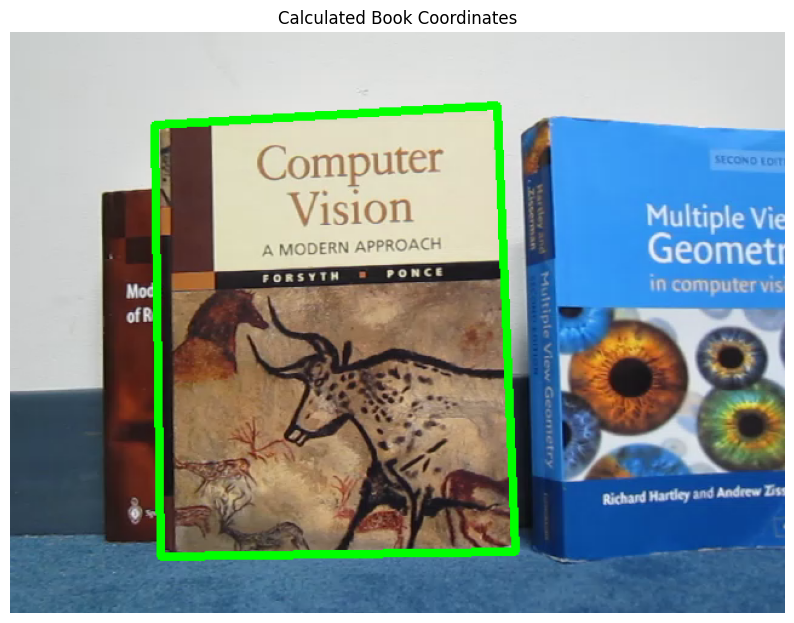

In [100]:
# -----------------------------------------------------------------------
# Part 1.3: Calculate where the book corners appear in the video frame.
# We project the four corners of the book COVER image through H to find
# the corresponding quadrilateral in the video frame.
# -----------------------------------------------------------------------

height, width = book_cover.shape[:2]

# Define the four corners of the book cover in cover-image pixel coordinates.
# Order: TL, TR, BR, BL (clockwise) — this order matters for polylines/fillPoly.
top_left     = [0, 0]
top_right    = [width - 1, 0]
bottom_left  = [0, height - 1]
bottom_right = [width - 1, height - 1]

corners = [top_left, top_right, bottom_right, bottom_left]

corners_transformed = []   # will hold the projected (x, y) in the video frame

# Project each corner through the homography H
for corner in corners:
    # Represent the corner as a homogeneous 3-vector [x, y, 1]
    corner_homogenous = np.array([corner[0], corner[1], 1.0])

    # Apply H: result is [x'*w, y'*w, w] in homogeneous coordinates
    p_mapped = np.dot(H, corner_homogenous)

    # Divide by w to get actual pixel coordinates in the video frame
    p_mapped = p_mapped / p_mapped[2]

    corners_transformed.append([p_mapped[0], p_mapped[1]])

print("Done")

# Convert to int32 for OpenCV drawing functions (polylines / fillConvexPoly
# require integer pixel coordinates).  Shape: (4, 2).
corners_dst = np.array(corners_transformed, dtype=np.int32)

# -----------------------------------------------------------------------
# Visualise: draw the projected book quad on the first video frame as a
# sanity check that H is pointing at the right place.
# -----------------------------------------------------------------------
frame_with_box = book_frame.copy()
cv2.polylines(frame_with_box, [corners_dst], isClosed=True, color=(0, 255, 0), thickness=5)

plt.figure(figsize=(10, 8))
plt.imshow(frame_with_box)
plt.title('Calculated Book Coordinates')
plt.axis('off')
plt.show()


### Crop AR Video Frames
The book and the videos provided have very different aspect ratios (the ratio of the image width to the image height).
- Crop each frame to fit onto the book cover.
- Crop each frame such that only its central region is used in the final output.
- After Getting the four corners of the book, you can calculate the dimensions of the needed cropped frame.

Movie is assumed to be wider than the book. An advanced addition would be to crop to either width or height, depending on ratio.

In [101]:
def crop_frame(frame, target_width, target_height):
    """
    Crops the CENTRAL region of `frame` to exactly (target_width x target_height)
    pixels, then resizes the result to (target_width, target_height).

    Why crop the centre?
        The AR source video is wider than the book cover.  Simply squishing the
        full frame would distort the image.  Instead we cut away the left/right
        edges (or top/bottom) so the most visually interesting central region
        fills the book rectangle.

    Logic:
        If the frame is wider than the target  → crop width, keep full height.
            center_x = midpoint of the frame width
            start_x  = center_x - target_width/2
            end_x    = start_x  + target_width
        If the frame is taller than the target → crop height, keep full width.
            (same idea vertically)

    After cropping, cv2.resize() scales the cropped patch to (target_width,
    target_height) so the output always matches the book cover dimensions.
    """
    height, width, _ = frame.shape

    if width > target_width:
        # ---- Wider than needed: crop horizontally, keep full height ----
        center_x = width // 2

        # Left boundary of the crop window (centred on center_x)
        start_x = center_x - (target_width // 2)
        end_x   = start_x + target_width

        # Slice columns start_x..end_x, keep all rows
        cropped_frame = frame[:, start_x : end_x]

        # Resize to the exact target dimensions (handles any rounding from //2)
        cropped_frame = cv2.resize(cropped_frame, (target_width, target_height))

    else:
        # ---- Taller than needed: crop vertically, keep full width ----
        center_y = height // 2

        start_y = center_y - (target_height // 2)
        end_y   = start_y + target_height

        # Slice rows start_y..end_y, keep all columns
        cropped_frame = frame[start_y : end_y, :]
        cropped_frame = cv2.resize(cropped_frame, (target_width, target_height))

    return cropped_frame


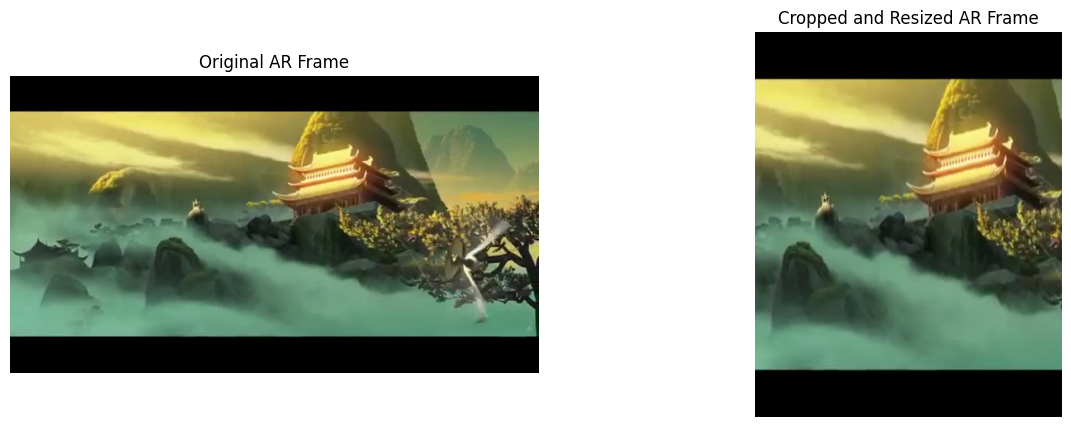

In [102]:
cropped_ar_frame = crop_frame(ar_frame, w_book, h_book)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(ar_frame)
ax1.set_title('Original AR Frame')
ax1.axis('off')

ax2.imshow(cropped_ar_frame)
ax2.set_title('Cropped and Resized AR Frame')
ax2.axis('off')
plt.show()

### Overlay the First Frame of the Two Videos
- Replace the computer vision book in the first video frame with the first cropped frame of the movie video to make the AR Effect.

To overlay 2 images: 
- The original image will have the book cover removed to completely black using a mask.
- The mask will be white, with the book polygon as black
- AND operation will be applied to keep background
- The new warped layer will be added on the background

In [103]:
def overlay_frame(ar_frame, H, corners_dst, visualize=False):
    """
    Composites an AR frame onto the book video frame using a mask-based approach.

    Steps:
      1. Warp the AR frame into the book video's perspective using our custom
         inverse_warp (H maps cover coords -> video frame coords).
      2. Build a binary mask the same size as the video frame:
           - Everywhere = white (255,255,255)  → keep video background
           - Inside the book quad = black (0,0,0) → punch a hole for the AR image
      3. AND the mask with the video frame to zero-out (black) the book region.
      4. ADD the warped AR image on top — its pixels fill in the hole because
         pixels outside the book quad are already zero in warped_ar.
         (No blending needed; the mask and warp are perfectly aligned.)

    Parameters:
        ar_frame    : the cropped & resized AR source frame (RGB, h_book x w_book)
        H           : homography that maps cover coords -> current video frame coords
        corners_dst : int32 (4,2) array of projected book corners for the mask
        visualize   : if True, shows intermediate steps as a 2x2 figure
    """
    # ---- Step 1: Warp ----
    # inverse_warp maps the AR frame (whose pixels are in cover-image space)
    # into the video-frame space using H. Pixels outside the book quad remain 0.
    warped_ar = inverse_warp(ar_frame, H, (book_frame.shape[0], book_frame.shape[1]))

    # ---- Step 2: Create mask ----
    # Start with a completely white image (same size / dtype as book_frame).
    mask = np.full_like(book_frame, 255, dtype=np.uint8)

    # Paint the book polygon BLACK — this is where we want the AR image to show.
    cv2.fillConvexPoly(mask, corners_dst, (0, 0, 0))

    # ---- Step 3: Remove book from background ----
    # bitwise_and zeros out every pixel inside the black polygon,
    # leaving the rest of the video frame untouched.
    background = cv2.bitwise_and(book_frame, mask)

    # ---- Step 4: Paste AR image ----
    # warped_ar is 0 outside the book quad and contains the AR content inside.
    # Adding it to background fills the hole with the AR image.
    final_ar_frame = cv2.add(background, warped_ar)

    if visualize:
        fig, axs = plt.subplots(2, 2, figsize=(10, 10))
        axs = axs.flatten()

        axs[0].imshow(warped_ar)
        axs[0].set_title('Warped AR Frame')
        axs[0].axis('off')

        axs[1].imshow(mask)
        axs[1].set_title('Mask for Background')
        axs[1].axis('off')

        axs[2].imshow(background)
        axs[2].set_title('Video Frame with Hole')
        axs[2].axis('off')

        axs[3].imshow(final_ar_frame)
        axs[3].set_title('First Frame Overlay')
        axs[3].axis('off')

        plt.tight_layout()
        plt.show()

    return final_ar_frame


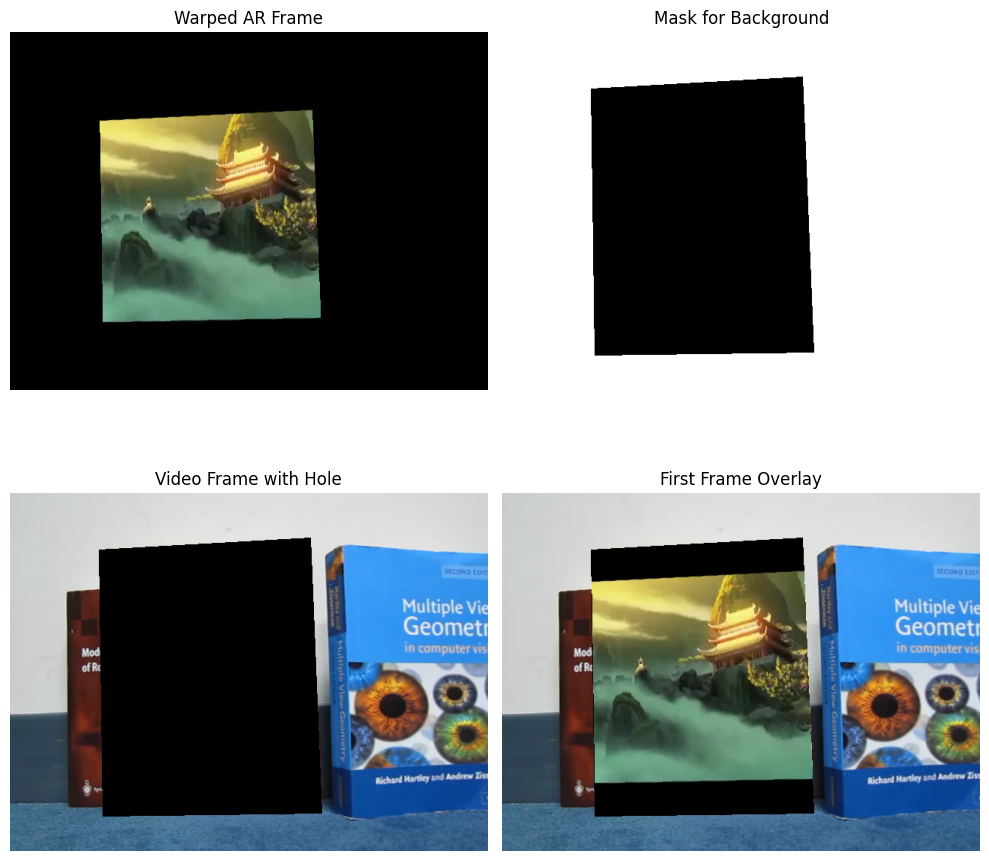

In [104]:
final_ar_frame = overlay_frame(cropped_ar_frame, H, corners_dst, visualize=True)

### Creating AR Application
- Overlay each cropped video frame to its corresponding frame of the book video
- Get the new location of the book in the following frame. 
- Compute the homography matrix between the vision book cover and all the frames.
- Overlay each frame.

In [105]:
import subprocess, os

# ============================================================
# Part 1.5 — Full AR Video Pipeline
# ============================================================
# For every frame pair (book_frame, ar_frame) we:
#   1. Detect SIFT features in the current book frame.
#   2. Match them against the fixed book COVER descriptors (des1 / kp1).
#   3. Run our manual RANSAC to get a robust homography H for THIS frame.
#   4. Validate H geometrically (convexity, area, bounds, aspect ratio).
#   5. Optionally smooth H with the previous frame's H to reduce jitter.
#   6. Crop the AR frame to match the projected book aspect ratio.
#   7. Warp the cropped AR frame onto the book region using bilinear_inverse_warp.
#   8. Composite the warped AR image over the book frame using a mask.
#   9. Write the composited frame to the output video.
# After all frames: mux audio from ar_source.mov using ffmpeg.
# ============================================================

# Re-open both videos from the beginning (they may have been read before)
book_vid2  = cv2.VideoCapture('data/book.mov')
ar_vid2    = cv2.VideoCapture('data/ar_source.mov')

# Read video properties from the book video
fps        = book_vid2.get(cv2.CAP_PROP_FPS)
frame_w    = int(book_vid2.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h    = int(book_vid2.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_book = int(book_vid2.get(cv2.CAP_PROP_FRAME_COUNT))
total_ar   = int(ar_vid2.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Book video:  {total_book} frames  {frame_w}x{frame_h}  {fps:.1f} fps')
print(f'AR video:    {total_ar} frames')

# Output video writer — mp4v codec, no audio yet (audio added at the end via ffmpeg)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter('data/ar_output_noaudio.mp4', fourcc, fps, (frame_w, frame_h))

# Counters for progress reporting
frame_count     = 0   # total frames processed
skip_count      = 0   # frames with no valid H at all (written as plain book frame)
fallback_count  = 0   # frames where we reused the last known-good H
fallback_streak = 0   # consecutive frame count of reusing stale H
MAX_FALLBACK    = 10  # after this many consecutive bad frames, stop overlaying
                      # (prevents badly misaligned AR from persisting too long)

# State for temporal reuse and smoothing
last_good_H             = None   # H from the most recent successfully validated frame
last_good_corners_array = None   # float corners from that frame
last_good_corners_dst   = None   # int32 corners from that frame
prev_H                  = None   # H from the immediately previous valid frame (for smoothing)

# Reference aspect ratio of the physical book cover (width / height)
book_aspect_ref = w_book / h_book


def _reproject_corners(H_mat):
    """
    Recompute the projected book corners after H has been modified (e.g. after smoothing).
    Returns (corners_float (4,2), corners_int32 (4,2)).
    """
    cover_c = np.array([[0, 0], [w_book - 1, 0],
                        [w_book - 1, h_book - 1], [0, h_book - 1]], dtype=np.float64)
    ph  = np.column_stack([cover_c, np.ones(4)])    # homogeneous (4,3)
    pr  = (H_mat @ ph.T).T                          # projected   (4,3)
    pr /= pr[:, 2:3]                                # normalise -> Cartesian
    arr = pr[:, :2]
    return arr, arr.astype(np.int32)


# ============================================================
# Main processing loop — one iteration per frame pair
# ============================================================
while True:
    ret_b, b_bgr = book_vid2.read()   # next book video frame (BGR)
    ret_a, a_bgr = ar_vid2.read()     # next AR source frame (BGR)

    # Stop if either video runs out of frames
    if not ret_b or not ret_a:
        break

    # Convert both frames to RGB (our warp/overlay functions work in RGB)
    b_rgb = cv2.cvtColor(b_bgr, cv2.COLOR_BGR2RGB)
    a_rgb = cv2.cvtColor(a_bgr, cv2.COLOR_BGR2RGB)

    # ------------------------------------------------------------------
    # Step 1 & 2: SIFT feature detection + matching
    # We match the COVER descriptors (des1 / kp1, computed once at the top)
    # against features detected fresh in this book frame.
    # Using up to 150 good matches gives RANSAC much more data to work with
    # compared to only using 50 — reduces the chance of a bad H slipping through.
    # ------------------------------------------------------------------
    gray_b       = cv2.cvtColor(b_bgr, cv2.COLOR_BGR2GRAY)
    kp_b, des_b  = sift.detectAndCompute(gray_b, None)

    matches_f = bf.knnMatch(des1, des_b, k=2)

    # Lowe's ratio test: only keep matches where the best match is clearly
    # better than the second-best (distance ratio < 0.75).
    # Sort by quality and keep the top 150.
    good_f = sorted(
        [m for m, n in matches_f if m.distance < 0.75 * n.distance],
        key=lambda x: x.distance
    )[:150]

    H_f             = None
    corners_array_f = None
    corners_dst_f   = None
    use_this        = False   # will be set True only if H passes all checks

    if len(good_f) >= 8:
        # Collect matched point coordinates
        src_f = np.float32([kp1[m.queryIdx].pt for m in good_f])   # cover points
        dst_f = np.float32([kp_b[m.trainIdx].pt for m in good_f])  # frame points

        # ------------------------------------------------------------------
        # Step 3: Robust homography via manual RANSAC
        # n_iters=2000  — more iterations = higher chance of finding a great
        #                 consensus set even with many outliers
        # threshold=3.0 — a projected point must be within 3 px of its
        #                 target to count as an inlier (tight = fewer false H)
        # ------------------------------------------------------------------
        H_f, inliers_f = ransac_homography(src_f, dst_f, n_iters=2000, threshold=3.0)

        # Require at least 15 inliers before trusting H
        if H_f is not None and inliers_f.sum() >= 15:

            # ------------------------------------------------------------------
            # Step 4a: Geometric validation (convexity, area, bounds)
            # ------------------------------------------------------------------
            valid, corners_array_f, corners_dst_f = is_valid_homography(
                H_f, frame_w, frame_h, w_book, h_book
            )

            if valid:
                # ------------------------------------------------------------------
                # Step 4b: Aspect-ratio guard
                # Even if the quad is convex, a badly estimated H can produce a
                # quad whose width/height ratio is very different from the real book.
                # We reject it if it deviates more than 40% from the true ratio.
                # ------------------------------------------------------------------
                proj_w = np.linalg.norm(corners_array_f[1] - corners_array_f[0])  # TL->TR width
                proj_h = np.linalg.norm(corners_array_f[3] - corners_array_f[0])  # TL->BL height
                ratio_ok = (proj_h > 0 and
                            abs((proj_w / proj_h) - book_aspect_ref) / book_aspect_ref < 0.4)

                if ratio_ok:
                    # ------------------------------------------------------------------
                    # Step 5: Light temporal smoothing
                    # Blend 80% of the current H with 20% of the previous frame's H.
                    # This dampens sudden jitter without introducing noticeable lag.
                    # Re-normalise so H[2,2] == 1 (standard homography convention).
                    # Then reproject corners to stay consistent with the smoothed H.
                    # ------------------------------------------------------------------
                    if prev_H is not None:
                        H_f       = 0.8 * H_f + 0.2 * prev_H
                        H_f      /= H_f[2, 2]
                        corners_array_f, corners_dst_f = _reproject_corners(H_f)

                    # Save this as the new 'last good' state
                    prev_H                  = H_f.copy()
                    last_good_H             = H_f
                    last_good_corners_array = corners_array_f
                    last_good_corners_dst   = corners_dst_f
                    fallback_streak         = 0   # reset the stale-H counter
                    use_this                = True

    # ------------------------------------------------------------------
    # Temporal fallback: if this frame produced no valid H, reuse the
    # last known-good one for up to MAX_FALLBACK consecutive frames.
    # Beyond that limit, write the plain book frame (no AR overlay).
    # ------------------------------------------------------------------
    if not use_this:
        if last_good_H is not None and fallback_streak < MAX_FALLBACK:
            # Borrow the last good homography and corners
            H_f             = last_good_H
            corners_array_f = last_good_corners_array
            corners_dst_f   = last_good_corners_dst
            fallback_count += 1
            fallback_streak += 1
        else:
            # No valid H and fallback limit reached — write the unmodified frame
            out.write(b_bgr)
            frame_count += 1
            skip_count  += 1
            continue

    # ------------------------------------------------------------------
    # Step 6: Crop the AR frame to the book's current projected aspect ratio
    # The book may look narrower or wider depending on camera angle, so we
    # compute the aspect ratio from the actual projected corners each frame.
    # ------------------------------------------------------------------
    bw_f       = np.linalg.norm(corners_array_f[1] - corners_array_f[0])  # projected width
    bh_f       = np.linalg.norm(corners_array_f[3] - corners_array_f[0])  # projected height
    book_asp_f = bw_f / bh_f if bh_f > 0 else book_aspect_ref

    h_a, w_a  = a_rgb.shape[:2]
    ar_asp_f  = w_a / h_a

    # Decide whether to crop width or height to match book_asp_f
    if ar_asp_f > book_asp_f:
        # AR frame is proportionally wider than the book projection
        # → keep full height, crop sides
        cw_f = int(h_a * book_asp_f)
        ch_f = h_a
    else:
        # AR frame is proportionally taller than the book projection
        # → keep full width, crop top/bottom
        cw_f = w_a
        ch_f = int(w_a / book_asp_f)

    # Crop the central region and resize to exactly the cover dimensions.
    # After this step, cropped_f is (h_book x w_book) — ready to warp.
    cropped_f = crop_frame(a_rgb, cw_f, ch_f)
    cropped_f = cv2.resize(cropped_f, (w_book, h_book))

    # ------------------------------------------------------------------
    # Step 7 & 8: Warp and composite
    # bilinear_inverse_warp: maps cropped_f (cover space) → video frame space
    #   using H. Pixels outside the book quad remain black (0).
    # mask_f: white image with the book quad punched black.
    # bitwise_and removes the book from the background (b_rgb & mask_f).
    # cv2.add pastes the warped AR image into the hole.
    # ------------------------------------------------------------------
    warped_f = bilinear_inverse_warp(cropped_f, H_f, (frame_h, frame_w))
    mask_f   = np.full((frame_h, frame_w, 3), 255, dtype=np.uint8)
    cv2.fillConvexPoly(mask_f, corners_dst_f, (0, 0, 0))   # black polygon = hole
    bg_f     = cv2.bitwise_and(b_rgb, mask_f)               # book region zeroed out
    result_f = cv2.add(bg_f, warped_f)                      # AR fills the hole

    # Convert back to BGR for VideoWriter and write the frame
    out.write(cv2.cvtColor(result_f, cv2.COLOR_RGB2BGR))
    frame_count += 1

    if frame_count % 20 == 0:
        print(f'  {frame_count}/{min(total_book, total_ar)} frames  '
              f'(fallback={fallback_count})')

# Release video handles and flush the output file
book_vid2.release()
ar_vid2.release()
out.release()
print(f'Done! {frame_count} frames  skipped={skip_count}  fallback={fallback_count}')

# ============================================================
# Audio muxing with ffmpeg
# ============================================================
# The VideoWriter above produces a video-only .mp4 (no audio track).
# ffmpeg is called as a subprocess to combine:
#   - video stream from ar_output_noaudio.mp4
#   - audio stream from ar_source.mov
# into a single ar_output.mp4.
#   -map 0:v:0  = take video from the first input
#   -map 1:a:0  = take audio from the second input
#   -c:v copy   = copy video stream without re-encoding (fast, lossless quality)
#   -c:a aac    = encode audio as AAC (standard for .mp4 containers)
#   -shortest   = stop when the shorter stream ends
# ============================================================
print('Adding audio from ar_source.mov ...')
mux_result = subprocess.run(
    ['ffmpeg', '-y',
     '-i', 'data/ar_output_noaudio.mp4',
     '-i', 'data/ar_source.mov',
     '-map', '0:v:0',
     '-map', '1:a:0',
     '-c:v', 'copy',
     '-c:a', 'aac',
     '-shortest',
     'data/ar_output.mp4'],
    capture_output=True, text=True
)
if mux_result.returncode == 0:
    os.remove('data/ar_output_noaudio.mp4')   # clean up intermediate file
    print('Audio muxed -> data/ar_output.mp4')
else:
    # ffmpeg not available or failed — keep the video-only file
    os.rename('data/ar_output_noaudio.mp4', 'data/ar_output.mp4')
    print('Audio mux failed; video saved without audio.')
    print(mux_result.stderr[-400:])


Book video:  641 frames  640x480  30.0 fps
AR video:    511 frames
  20/511 frames  (fallback=0)
  40/511 frames  (fallback=0)
  60/511 frames  (fallback=0)
  80/511 frames  (fallback=0)
  100/511 frames  (fallback=0)
  120/511 frames  (fallback=0)
  140/511 frames  (fallback=0)
  160/511 frames  (fallback=0)
  180/511 frames  (fallback=0)
  200/511 frames  (fallback=0)
  220/511 frames  (fallback=0)
  240/511 frames  (fallback=0)
  260/511 frames  (fallback=0)
  280/511 frames  (fallback=0)
  300/511 frames  (fallback=0)
  320/511 frames  (fallback=0)
  340/511 frames  (fallback=0)
  360/511 frames  (fallback=0)
  380/511 frames  (fallback=0)
  400/511 frames  (fallback=0)
  420/511 frames  (fallback=0)
  440/511 frames  (fallback=0)
  460/511 frames  (fallback=0)
  480/511 frames  (fallback=0)
  500/511 frames  (fallback=0)
Done! 511 frames  skipped=0  fallback=0
Adding audio from ar_source.mov ...
Audio muxed -> data/ar_output.mp4


Book projection in video: 283.1 x 356.1 px
Book aspect ratio (w/h):  0.7952
AR video dimensions:      640 x 360
Crop window: 286 x 360
cropped_ar_frame shape: (440, 350, 3)


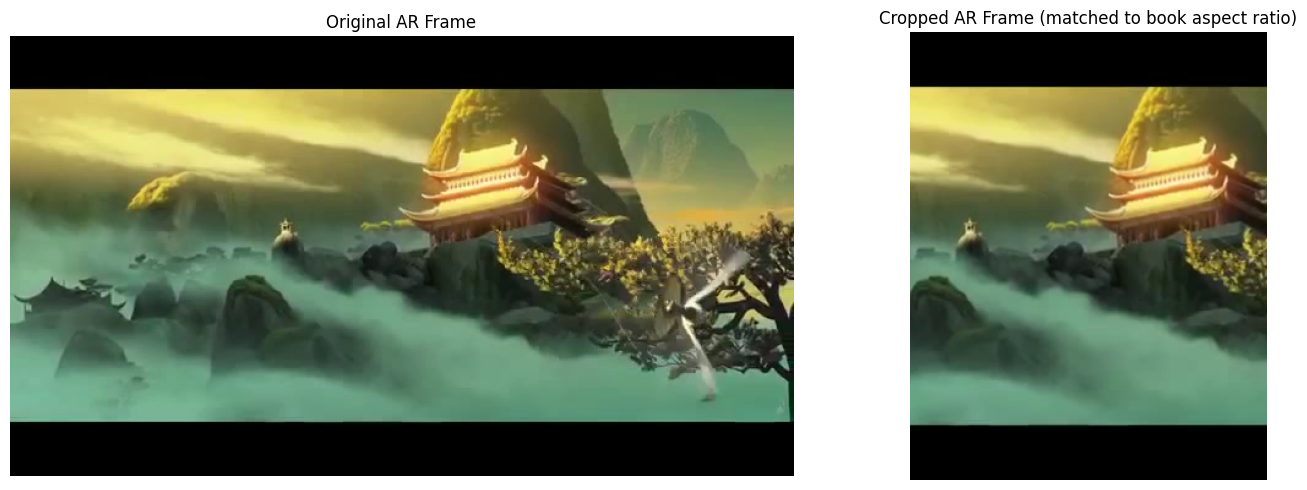

In [106]:
# -----------------------------------------------------------------------
# Part 1.4: Crop the first AR frame to match the book's projected aspect ratio.
#
# The book cover appears as a quadrilateral in the video frame.
# Its projected width and height (in pixels) determine the aspect ratio we
# need to match so the AR content fills the book without stretching.
# -----------------------------------------------------------------------

corners_array = np.array(corners_transformed)   # (4,2) float array of projected corners

# Euclidean distance between corners to get projected dimensions in pixels
book_w_in_vid = np.linalg.norm(corners_array[1] - corners_array[0])  # TL -> TR (width)
book_h_in_vid = np.linalg.norm(corners_array[3] - corners_array[0])  # TL -> BL (height)

print(f'Book projection in video: {book_w_in_vid:.1f} x {book_h_in_vid:.1f} px')
print(f'Book aspect ratio (w/h):  {book_w_in_vid / book_h_in_vid:.4f}')
print(f'AR video dimensions:      {w_ar} x {h_ar}')

ar_aspect   = w_ar / h_ar                      # AR source aspect ratio
book_aspect = book_w_in_vid / book_h_in_vid    # book projection aspect ratio

if ar_aspect > book_aspect:
    # AR frame is proportionally WIDER than the book
    # We want to cut the sides: keep full height, reduce width to match the ratio.
    # New width = height * book_aspect
    crop_w = int(h_ar * book_aspect)
    crop_h = h_ar
else:
    # AR frame is proportionally TALLER than the book
    # We want to cut the top/bottom: keep full width, reduce height.
    # New height = width / book_aspect
    crop_w = w_ar
    crop_h = int(w_ar / book_aspect)

print(f'Crop window: {crop_w} x {crop_h}')

# crop_frame() slices the central (crop_w x crop_h) region of ar_frame,
# then cv2.resize() scales it to exactly (w_book x h_book) pixels —
# the same dimensions as the cover image — so inverse_warp can map it directly.
cropped_ar_frame = crop_frame(ar_frame, crop_w, crop_h)
cropped_ar_frame = cv2.resize(cropped_ar_frame, (w_book, h_book))

print(f'cropped_ar_frame shape: {cropped_ar_frame.shape}')  # should be (h_book, w_book, 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(ar_frame)
ax1.set_title('Original AR Frame')
ax1.axis('off')

ax2.imshow(cropped_ar_frame)
ax2.set_title('Cropped AR Frame (matched to book aspect ratio)')
ax2.axis('off')

plt.tight_layout()
plt.show()
